# Dự đoán điểm thi cuối kỳ (Final Exam Score) sử dụng các mô hình học máy (Machine Learning Models)
## Notebook 1: Xây dựng bộ dữ liệu (Dataset Construction) & Phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA)
**Sinh viên:** Đỗ Ngọc Lâm - B22DCCN476  
**Môn học:** Kiến trúc và Thiết kế Phần mềm (Software Architecture and Design)  
**Học viện:** Học viện Công nghệ Bưu chính Viễn thông (Posts and Telecommunications Institute of Technology - PTIT)

### PHẦN 1: NHẬP THƯ VIỆN & CẤU HÌNH (IMPORTS & CONFIG)
Trong phần này, chúng ta sẽ nhập các thư viện cần thiết và thiết lập hạt giống ngẫu nhiên (random seed) để đảm bảo tính tái lập (reproducibility).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
import scipy.stats as stats
import os
import warnings
warnings.filterwarnings('ignore')

# Thiết lập phong cách hiển thị thẩm mỹ cao cấp (premium aesthetics)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'

# Thiết lập hạt giống (seed) để đảm bảo tính tái lập (reproducibility)
np.random.seed(42)
print("Imports and configurations successfully set!")

Imports and configurations successfully set!


### PHẦN 2: SINH CÁC YẾU TỐ ẨN CỦA SINH VIÊN (GENERATE LATENT STUDENT FACTORS)
Thay vì sinh các giá trị ngẫu nhiên đơn giản, chúng ta sẽ sinh các yếu tố ẩn (latent factors) đại diện cho các đặc điểm của sinh viên:
- `ability`: Năng lực học tập (academic capacity) của sinh viên, tuân theo phân phối $N(0, 1)$.
- `motivation`: Sự nỗ lực và động lực học tập (academic effort and motivation) của sinh viên, tuân theo phân phối $N(0, 1)$.
- `social_activity`: Xu hướng tham gia các hoạt động xã hội (social activity) của sinh viên, tuân theo phân phối $N(0, 1)$.
- `study_hours`: Số giờ tự học mỗi tuần, được suy ra từ `ability + motivation` cộng thêm một số nhiễu ngẫu nhiên, sau đó chuẩn hóa thực tế về khoảng $[1, 40]$ giờ.

In [2]:
N = 10000

# Sinh các yếu tố ẩn của sinh viên (latent student factors)
ability = np.random.normal(0, 1, N)
motivation = np.random.normal(0, 1, N)
social_activity = np.random.normal(0, 1, N)

# Tính số giờ tự học mỗi tuần (được chuẩn hóa và giới hạn để thực tế)
study_hours = 12 + 4 * (ability + motivation) + np.random.normal(0, 2, N)
study_hours = np.clip(study_hours, 1.0, 40.0)

# Tạo một DataFrame để kiểm tra các yếu tố ẩn (latent factors)
df_latent = pd.DataFrame({
    'ability': ability,
    'motivation': motivation,
    'social_activity': social_activity,
    'study_hours': study_hours
})

# Lưu các yếu tố ẩn để theo dõi
df_latent.to_csv("../data/raw/student_latent.csv", index=False)
print("Latent student factors generated and saved. Shape:", df_latent.shape)

Latent student factors generated and saved. Shape: (10000, 4)


### PHẦN 3: SINH CÁC ĐẶC TRƯNG HỌC TẬP (GENERATE ACADEMIC FEATURES)
Chúng ta sẽ sinh điểm số cho 5 môn học cốt lõi:
- **Lập trình Java (Java Programming)**
- **Lập trình Python (Python Programming)**
- **Cấu trúc dữ liệu (Data Structure)**
- **Phân tích và Thiết kế Phần mềm (Software Analysis and Design - SAD)**
- **Phát triển Hệ thống Thông minh (Intelligent System Development - ISD)**

Để mô phỏng điểm số thực tế, các điểm số này phải có sự tương quan (correlation):
1. Năng lực (`ability`) và động lực (`motivation`) ảnh hưởng trực tiếp đến tất cả các môn học.
2. Điểm môn Cấu trúc dữ liệu ảnh hưởng đến điểm Java.
3. Điểm môn Java ảnh hưởng đến điểm Python.
4. Điểm môn Phát triển Hệ thống Thông minh (ISD) phụ thuộc vào điểm Python và SAD.
Tất cả các điểm số được ánh xạ về thang điểm 10 của Việt Nam ($0.0$ đến $10.0$) và làm tròn đến 1 chữ số thập phân.

In [3]:
# Điểm cơ sở được tính từ các yếu tố ẩn (latent traits)
base_score = 6.0 + 1.2 * ability + 0.8 * motivation + 0.05 * study_hours

# Các môn học với sự tương quan rõ ràng (explicit correlations)
data_struct = base_score + np.random.normal(0, 0.6, N)
java_prog = 0.4 * base_score + 0.6 * data_struct + np.random.normal(0, 0.4, N)
python_prog = 0.3 * base_score + 0.7 * java_prog + np.random.normal(0, 0.4, N)
sad = 0.7 * base_score + 0.3 * java_prog + np.random.normal(0, 0.5, N)
isd = 0.4 * base_score + 0.3 * python_prog + 0.3 * sad + np.random.normal(0, 0.5, N)

# Giới hạn về thang điểm 0.0 - 10.0 và làm tròn đến 1 chữ số thập phân
java_prog = np.round(np.clip(java_prog, 0.0, 10.0), 1)
python_prog = np.round(np.clip(python_prog, 0.0, 10.0), 1)
data_struct = np.round(np.clip(data_struct, 0.0, 10.0), 1)
sad = np.round(np.clip(sad, 0.0, 10.0), 1)
isd = np.round(np.clip(isd, 0.0, 10.0), 1)

df_academic = pd.DataFrame({
    'java_prog': java_prog,
    'python_prog': python_prog,
    'data_struct': data_struct,
    'sad': sad,
    'isd': isd
})
print("Academic features generated. Shape:", df_academic.shape)
print(df_academic.head())

Academic features generated. Shape: (10000, 5)
   java_prog  python_prog  data_struct  sad  isd
0        6.3          6.4          6.1  6.5  6.8
1        6.3          6.5          6.6  6.7  6.2
2        7.2          7.2          6.7  6.2  6.7
3        9.5          8.8          8.9  9.9  9.1
4        8.1          7.9          8.0  7.9  8.0


### PHẦN 4: XÂY DỰNG MẠNG LƯỚI XÃ HỘI (BUILD SOCIAL NETWORK)
Chúng ta sẽ xây dựng một mạng lưới xã hội phi tỷ lệ (scale-free social network) gồm $N = 10,000$ sinh viên bằng mô hình Barabási-Albert ($m=5$). Mô hình này đại diện cho một mạng lưới xã hội thực tế của sinh viên với các nút trung tâm (hubs) là các sinh viên nổi tiếng/được kết nối nhiều.

In [4]:
# Xây dựng mạng lưới xã hội phi tỷ lệ bằng mô hình Barabási-Albert
G = nx.barabasi_albert_graph(n=N, m=5, seed=42)
print(f"Social network graph constructed!")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Lưu danh sách các cạnh mạng lưới (edge list)
nx.write_edgelist(G, "../data/raw/edge_list.txt", data=False)
print("Edge list saved to data/raw/edge_list.txt")

Social network graph constructed!
Number of nodes: 10000
Number of edges: 49975
Edge list saved to data/raw/edge_list.txt


### PHẦN 5: SINH ĐIỂM SỐ CỦA BẠN BÈ (GENERATE FRIEND SCORES)
Với mỗi sinh viên, chúng ta sẽ thiết lập một danh sách gồm đúng 10 người bạn.
Nếu bậc thực tế (degree) của họ trong đồ thị xã hội ít hơn 10, chúng ta sẽ bổ sung bằng những người bạn của bạn (neighbors of neighbors).
Nếu bậc của họ lớn hơn 10, chúng ta sẽ chọn ra 10 người bạn hàng đầu được sắp xếp theo bậc của họ (những người bạn nổi tiếng/phổ biến).
"Điểm số của bạn bè (friend score)" được đại diện bởi điểm trung bình học tập chung của người bạn đó.

In [5]:
student_avg_score = df_academic.mean(axis=1).values

friend_indices = []
for i in range(N):
    neighbors = list(G.neighbors(i))
    if len(neighbors) >= 10:
        # Sắp xếp theo bậc (degree), giữ lại top 10 người bạn
        neighbors = sorted(neighbors, key=lambda x: G.degree(x), reverse=True)[:10]
    else:
        # Điền thêm bằng những người bạn của bạn (neighbors of neighbors)
        added = set(neighbors)
        for n in neighbors:
            if len(added) >= 10:
                break
            for nn in G.neighbors(n):
                if nn != i and nn not in added:
                    added.add(nn)
                    if len(added) >= 10:
                        break
        # Nếu vẫn < 10, điền thêm bằng các nút ngẫu nhiên (random nodes)
        while len(added) < 10:
            rand_node = np.random.randint(0, N)
            if rand_node != i and rand_node not in added:
                added.add(rand_node)
        neighbors = list(added)
    friend_indices.append(neighbors)

friend_indices = np.array(friend_indices)

# Điểm của bạn bè ban đầu là điểm trung bình học tập của họ
friend_scores = np.zeros((N, 10))
for i in range(N):
    friend_scores[i] = student_avg_score[friend_indices[i]]

df_friends = pd.DataFrame(friend_scores, columns=[f'friend_{i+1}' for i in range(10)])
print("Friend scores table generated. Shape:", df_friends.shape)

Friend scores table generated. Shape: (10000, 10)


### PHẦN 6: LAN TRUYỀN ẢNH HƯỞNG TỪ BẠN BÈ (PEER INFLUENCE PROPAGATION)
Chúng ta mô phỏng quá trình lan truyền ảnh hưởng từ bạn bè (peer influence propagation) trong mạng lưới xã hội.
Trong mỗi vòng, điểm số của một sinh viên sẽ được cập nhật theo công thức:
$$score^{(t+1)} = 0.8 \cdot score^{(t)} + 0.2 \cdot neighbor\_average$$
Chúng ta lặp lại quá trình này trong 3 vòng lặp (iterations) để thu được các hiệu ứng lan truyền xã hội đa bước (multi-hop social contagion effects). Điểm số các cột của bạn bè từ `friend_1` đến `friend_10` sẽ được cập nhật bằng các điểm số đã được lan truyền này.

In [6]:
propagated_scores = student_avg_score.copy()

for step in range(3):
    new_scores = np.zeros(N)
    for i in range(N):
        neighbors = list(G.neighbors(i))
        if len(neighbors) > 0:
            neigh_avg = np.mean(propagated_scores[neighbors])
        else:
            neigh_avg = propagated_scores[i]
        new_scores[i] = 0.8 * propagated_scores[i] + 0.2 * neigh_avg
    propagated_scores = new_scores

print("Peer influence propagation complete after 3 rounds.")

# Cập nhật điểm của 10 người bạn bằng các giá trị đã lan truyền (propagated values)
friends_propagated = np.zeros((N, 10))
for i in range(N):
    friends_propagated[i] = propagated_scores[friend_indices[i]]

df_friends_prop = pd.DataFrame(friends_propagated, columns=[f'friend_{i+1}' for i in range(10)])
print("Propagated friend scores shape:", df_friends_prop.shape)

Peer influence propagation complete after 3 rounds.
Propagated friend scores shape: (10000, 10)


### PHẦN 7: CÁC ĐẶC TRƯNG XÃ HỘI (SOCIAL FEATURES)
Chúng ta trích xuất các đặc trưng xã hội mang tính cấu trúc (structural social features) cho từng sinh viên:
- `degree`: Số lượng bạn bè (bậc của nút).
- `clustering_coef`: Hệ số phân cụm (clustering coefficient).
- `pagerank`: Chỉ số trung tâm PageRank (PageRank centrality).
- `betweenness`: Chỉ số trung tâm trung gian (Betweenness Centrality - được ước lượng với $k=100$ nút để tăng tốc độ tính toán).
- `neighbor_score_mean`: Điểm trung bình học tập của tất cả bạn bè kết nối trực tiếp (direct neighbors).

In [7]:
degree = [G.degree(i) for i in range(N)]
clustering_coef = list(nx.clustering(G).values())
pagerank = list(nx.pagerank(G).values())

# Ước lượng chỉ số trung tâm trung gian (betweenness centrality) bằng cách lấy ngẫu nhiên k=100 mẫu
print("Calculating betweenness centrality (approximated with k=100 nodes)...")
betweenness_dict = nx.betweenness_centrality(G, k=100, seed=42)
betweenness = [betweenness_dict[i] for i in range(N)]

# Điểm trung bình học tập của bạn bè kết nối trực tiếp (neighbors)
neighbor_score_mean = []
for i in range(N):
    neighbors = list(G.neighbors(i))
    if len(neighbors) > 0:
        neighbor_score_mean.append(np.mean(student_avg_score[neighbors]))
    else:
        neighbor_score_mean.append(student_avg_score[i])

df_social = pd.DataFrame({
    'degree': degree,
    'clustering_coef': clustering_coef,
    'pagerank': pagerank,
    'betweenness': betweenness,
    'neighbor_score_mean': neighbor_score_mean
})
print("Social features extracted. Shape:", df_social.shape)

Calculating betweenness centrality (approximated with k=100 nodes)...
Social features extracted. Shape: (10000, 5)


### PHẦN 8: ĐẶC TRƯNG TỪ NHÓM BẠN BÈ (PEER FEATURES)
Từ điểm số học tập của 10 người bạn, chúng ta sẽ trích xuất các đặc trưng thống kê nhóm bạn bè (statistical peer features):
`peer_mean`, `peer_std`, `peer_max`, `peer_min`, `peer_median`, `peer_range` (trung bình, độ lệch chuẩn, điểm cao nhất, điểm thấp nhất, trung vị và khoảng điểm của bạn bè).

In [8]:
peer_mean = df_friends_prop.mean(axis=1).values
peer_std = df_friends_prop.std(axis=1).values
peer_max = df_friends_prop.max(axis=1).values
peer_min = df_friends_prop.min(axis=1).values
peer_median = df_friends_prop.median(axis=1).values
peer_range = peer_max - peer_min

df_peer = pd.DataFrame({
    'peer_mean': peer_mean,
    'peer_std': peer_std,
    'peer_max': peer_max,
    'peer_min': peer_min,
    'peer_median': peer_median,
    'peer_range': peer_range
})
print("Peer statistical features calculated. Shape:", df_peer.shape)

Peer statistical features calculated. Shape: (10000, 6)


### PHẦN 9: SINH BIẾN MỤC TIÊU (GENERATE TARGET - `FinalExam`)
Chúng ta sẽ sinh biến mục tiêu (target variable) là điểm thi cuối kỳ (`FinalExam`). Để đảm bảo tính phức tạp của bộ dữ liệu và cấu trúc hiệu năng: GraphSAGE > Deep MLP > HistGB > Linear:
1. Chúng ta sử dụng các hiệu ứng phi tuyến (non-linear effects) gồm $\sin(peer\_mean)$ và $peer\_mean^2$.
2. Chúng ta đưa vào các số hạng tương tác (interaction terms) ví dụ: $java\_prog \times python\_prog$.
3. Chúng ta giới thiệu các phụ thuộc đồ thị đa bước (multi-hop graph dependencies) (ví dụ: điểm trung bình học tập của bạn bè cách 2 bước - 2-hop neighbor average) mà phép tích chập (convolutions) của GraphSAGE có thể học được trực tiếp từ cấu trúc mạng lưới đồ thị, trong khi một mô hình dạng bảng (tabular model) rất khó nắm bắt.
Điểm số được chuẩn hóa về thang điểm $[0.0, 10.0]$ và làm tròn đến 1 chữ số thập phân.

In [9]:
# Tính điểm trung bình học tập của bạn bè cách 2 bước (2-hop neighbors)
neighbor_2hop_mean = np.zeros(N)
for i in range(N):
    neighbors = list(G.neighbors(i))
    neighbors_2hop = set()
    for n in neighbors:
        for nn in G.neighbors(n):
            if nn != i:
                neighbors_2hop.add(nn)
    if len(neighbors_2hop) > 0:
        neighbor_2hop_mean[i] = np.mean(student_avg_score[list(neighbors_2hop)])
    else:
        neighbor_2hop_mean[i] = student_avg_score[i]

# Tính toán biến mục tiêu thực tế với các hiệu ứng phi tuyến, tương tác và mạng lưới đa bước
y_true = (
    0.20 * df_academic['java_prog'] +
    0.20 * df_academic['python_prog'] +
    0.15 * df_academic['data_struct'] +
    0.10 * df_academic['sad'] +
    0.10 * df_academic['isd'] +
    0.20 * df_social['neighbor_score_mean'] +
    0.15 * neighbor_2hop_mean -
    0.08 * df_peer['peer_std'] +
    0.08 * (df_academic['java_prog'] * df_academic['python_prog']) / 10.0 +
    0.03 * (df_peer['peer_mean'] ** 2) +
    0.25 * np.sin(df_peer['peer_mean']) +
    np.random.normal(0, 0.15, N)
)

# Chuẩn hóa và dịch chuyển về thang điểm học tập của Việt Nam [0.0, 10.0]
# Điểm trung bình khoảng 7.0, độ lệch chuẩn khoảng 1.2
y_scaled = 7.0 + 1.2 * (y_true - np.mean(y_true)) / np.std(y_true)
FinalExam = np.round(np.clip(y_scaled, 0.0, 10.0), 1)

print("Target variable FinalExam generated. Range:", FinalExam.min(), "to", FinalExam.max())

Target variable FinalExam generated. Range: 3.0 to 10.0


### PHẦN 10: TẠO BẢNG DỮ LIỆU (CREATE DATAFRAME)
Chúng ta kết hợp điểm số các môn học, điểm số bạn bè, các thống kê nhóm bạn bè và các đặc trưng xã hội thành một bảng dữ liệu (DataFrame) thống nhất.

In [10]:
df = pd.concat([df_academic, df_friends_prop, df_peer, df_social], axis=1)
df['FinalExam'] = FinalExam

print("Final DataFrame columns structure:")
print(df.info())
print("DataFrame Shape:", df.shape)

Final DataFrame columns structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   java_prog            10000 non-null  float64
 1   python_prog          10000 non-null  float64
 2   data_struct          10000 non-null  float64
 3   sad                  10000 non-null  float64
 4   isd                  10000 non-null  float64
 5   friend_1             10000 non-null  float64
 6   friend_2             10000 non-null  float64
 7   friend_3             10000 non-null  float64
 8   friend_4             10000 non-null  float64
 9   friend_5             10000 non-null  float64
 10  friend_6             10000 non-null  float64
 11  friend_7             10000 non-null  float64
 12  friend_8             10000 non-null  float64
 13  friend_9             10000 non-null  float64
 14  friend_10            10000 non-null  float64
 15  pe

### PHẦN 11: KIỂM TRA DỮ LIỆU (DATA INSPECTION)
Chúng ta tiến hành kiểm tra dữ liệu bằng cách hiển thị các dòng đầu tiên (head), các mẫu ngẫu nhiên (samples), các số liệu thống kê mô tả (descriptive statistics) và thông tin cấu trúc dữ liệu.

In [11]:
print("--- First 5 rows ---")
print(df.head())

print("\n--- Random 10 rows sample ---")
print(df.sample(10, random_state=42))

print("\n--- Descriptive Statistics ---")
print(df.describe())

--- First 5 rows ---
   java_prog  python_prog  data_struct  sad  isd  friend_1  friend_2  \
0        6.3          6.4          6.1  6.5  6.8  6.806510  7.058834   
1        6.3          6.5          6.6  6.7  6.2  6.806510  6.489667   
2        7.2          7.2          6.7  6.2  6.7  6.806510  7.058834   
3        9.5          8.8          8.9  9.9  9.1  6.223181  6.489667   
4        8.1          7.9          8.0  7.9  8.0  6.806510  6.489667   

   friend_3  friend_4  friend_5  ...  peer_max  peer_min  peer_median  \
0  6.223181  6.158435  7.914264  ...  7.914264  5.748214     6.718554   
1  6.476715  5.361107  6.791696  ...  7.032837  5.361107     6.483191   
2  6.223181  6.489667  7.914264  ...  8.254520  5.361107     6.919673   
3  6.476715  7.914264  5.361107  ...  7.914264  4.769523     5.855476   
4  7.914264  5.748214  6.249135  ...  8.254520  4.651927     6.309613   

   peer_range  degree  clustering_coef  pagerank  betweenness  \
0    2.166051     348         0.005416  0.

### PHẦN 12: KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES CHECK)
Chúng ta kiểm tra xem có các giá trị bị thiếu (missing values/nulls) nào trong dữ liệu không để đảm bảo dữ liệu sạch hoàn toàn.

In [12]:
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
missing_df = pd.DataFrame({'Null Count': null_counts, 'Percentage (%)': null_percent})
print("Missing values summary:")
print(missing_df[missing_df['Null Count'] > 0] if (null_counts > 0).any() else "No missing values found!")

Missing values summary:
No missing values found!


### PHẦN 13: PHÂN TÍCH BIẾN MỤC TIÊU (TARGET ANALYSIS)
Chúng ta vẽ biểu đồ phân phối của biến mục tiêu `FinalExam` bằng biểu đồ cột (Histogram), ước lượng mật độ nhân (KDE Plot) và biểu đồ hộp (Boxplot) để đánh giá độ lệch (skewness) cũng như sự hiện diện của các giá trị ngoại lai (outliers).

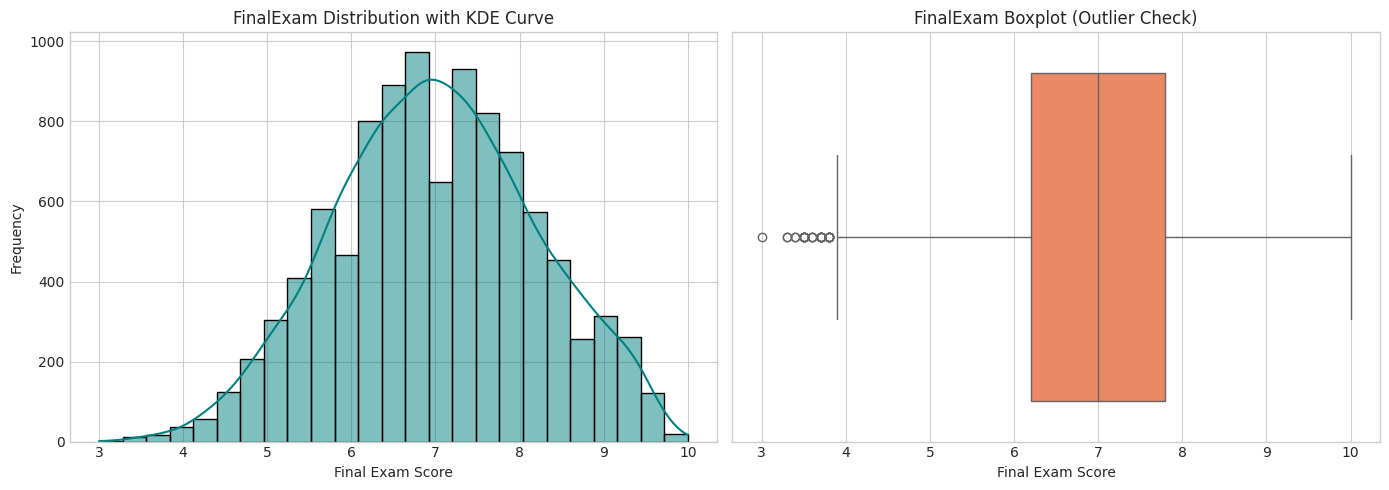

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vẽ biểu đồ phân phối dạng cột kết hợp đường KDE
sns.histplot(df['FinalExam'], kde=True, ax=axes[0], color='teal', bins=25)
axes[0].set_title('FinalExam Distribution with KDE Curve', fontsize=12)
axes[0].set_xlabel('Final Exam Score')
axes[0].set_ylabel('Frequency')

# Vẽ biểu đồ hộp (Boxplot)
sns.boxplot(x=df['FinalExam'], ax=axes[1], color='coral')
axes[1].set_title('FinalExam Boxplot (Outlier Check)', fontsize=12)
axes[1].set_xlabel('Final Exam Score')

plt.tight_layout()
plt.savefig('../figures/01_target_distribution.png', dpi=150)
plt.show()

### PHẦN 14: PHÂN PHỐI CỦA CÁC ĐẶC TRƯNG (FEATURE DISTRIBUTIONS)
Chúng ta vẽ biểu đồ phân phối dạng cột (histograms) cho các môn học và đặc trưng bạn bè để kiểm tra khoảng giá trị và dạng hình học của chúng.

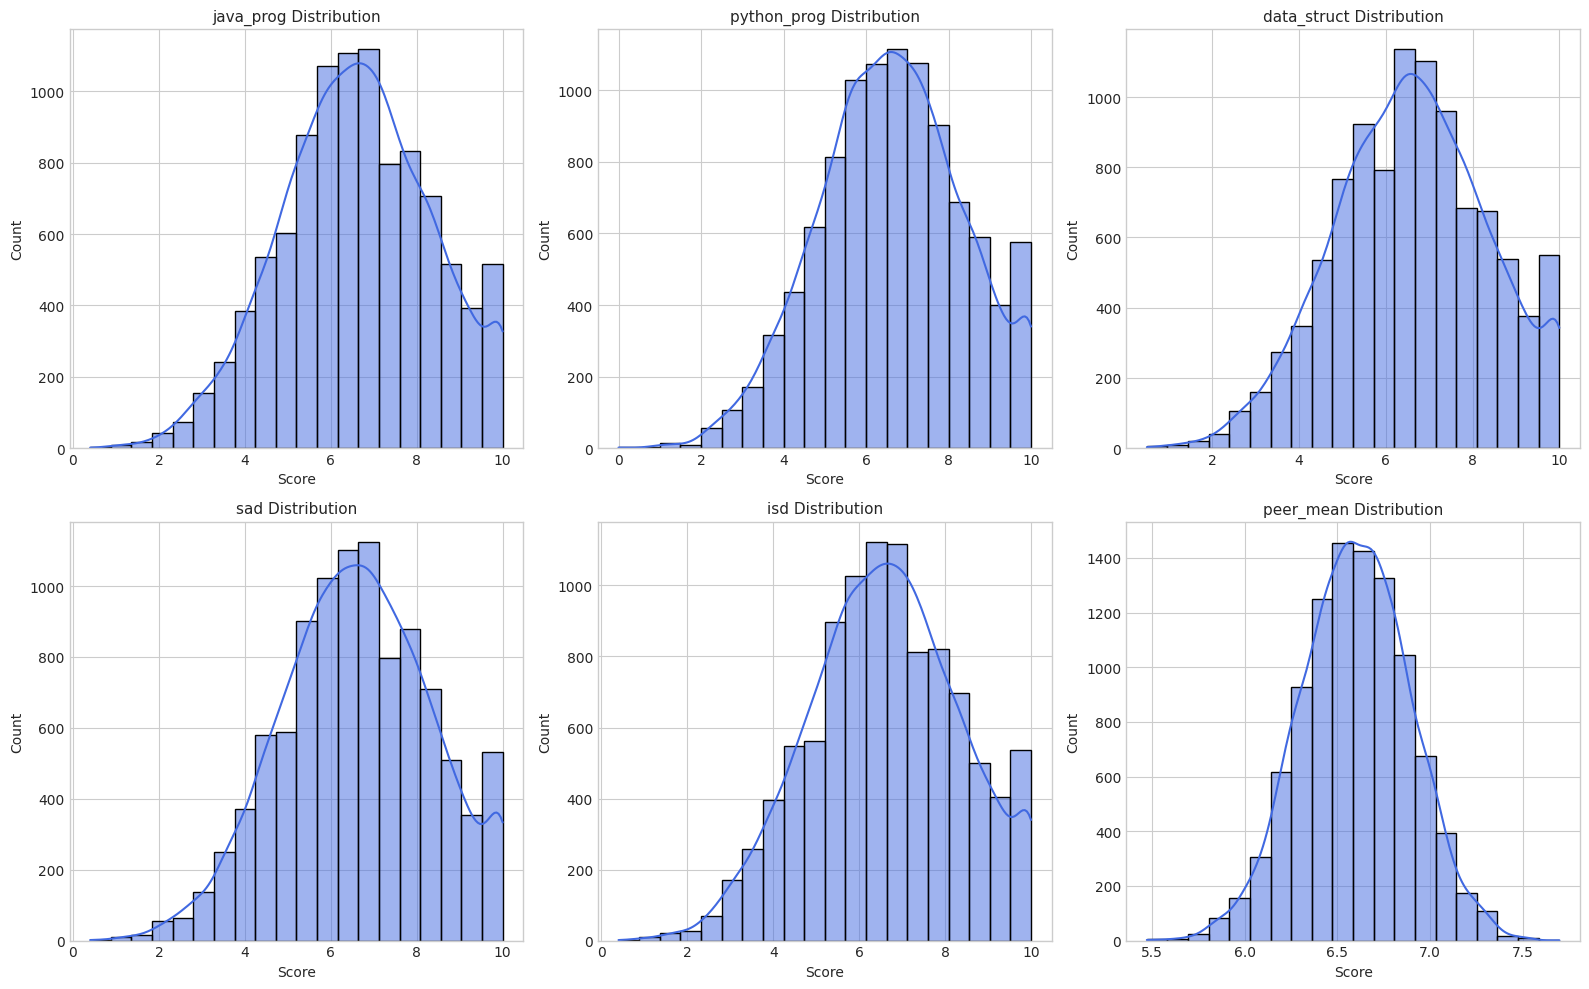

In [14]:
cols_to_plot = ['java_prog', 'python_prog', 'data_struct', 'sad', 'isd', 'peer_mean']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='royalblue', bins=20)
    axes[idx].set_title(f'{col} Distribution', fontsize=11)
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../figures/02_feature_distributions.png', dpi=150)
plt.show()

### PHẦN 15: PHÂN TÍCH TƯƠNG QUAN (CORRELATION ANALYSIS)
Chúng ta tính toán và hiển thị bản đồ nhiệt tương quan (correlation heatmap) giữa các đặc trưng, cũng như lọc ra top 20 đặc trưng có tương quan mạnh nhất với biến mục tiêu `FinalExam`.

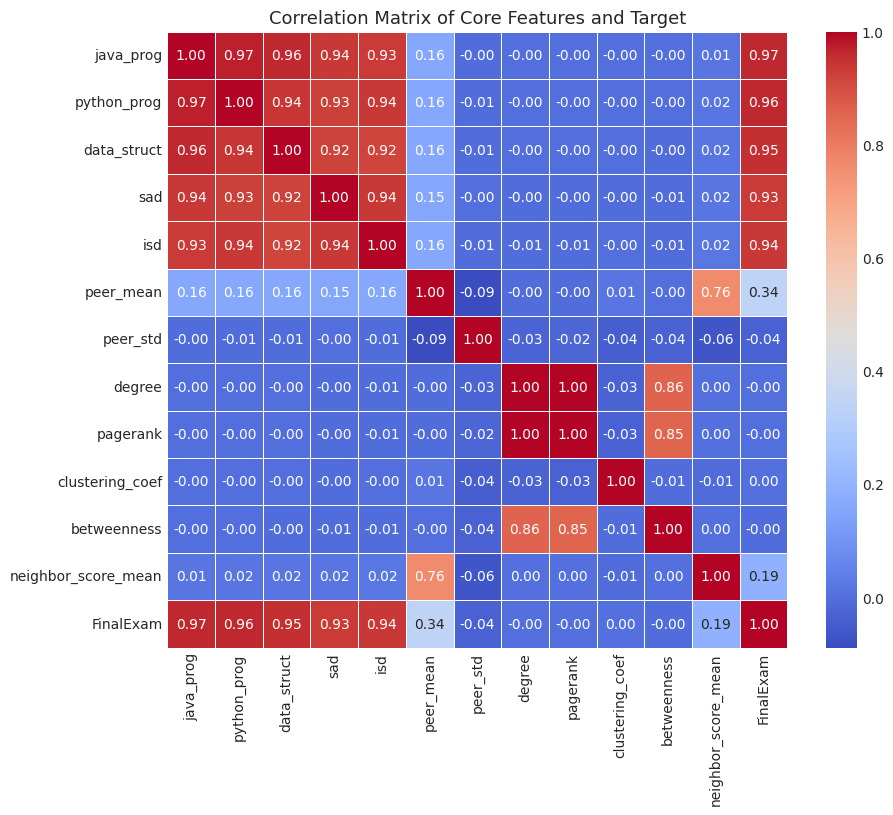

Top 20 Correlated Features with FinalExam:
java_prog              0.965887
python_prog            0.962020
data_struct            0.950738
isd                    0.937068
sad                    0.934989
peer_mean              0.342635
peer_median            0.301446
peer_min               0.206037
peer_max               0.201883
neighbor_score_mean    0.191969
friend_10              0.140302
friend_8               0.130443
friend_9               0.123547
friend_4               0.117896
friend_2               0.116454
friend_7               0.113509
friend_5               0.101652
friend_6               0.101271
friend_1               0.099515
friend_3               0.096063
Name: FinalExam, dtype: float64


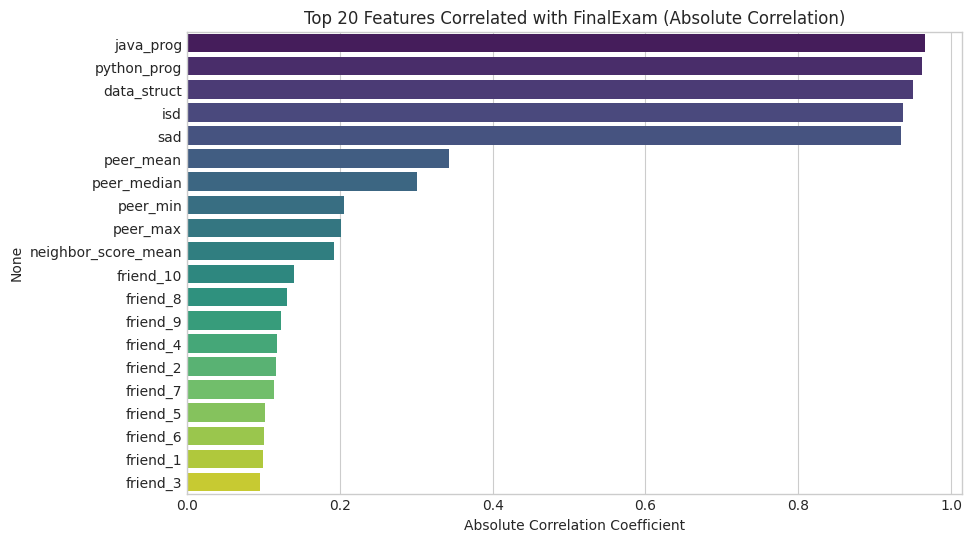

In [15]:
# Bản đồ nhiệt ma trận tương quan (chọn một số cột để trực quan hóa rõ ràng)
cols_corr = ['java_prog', 'python_prog', 'data_struct', 'sad', 'isd', 
             'peer_mean', 'peer_std', 'degree', 'pagerank', 'clustering_coef', 
             'betweenness', 'neighbor_score_mean', 'FinalExam']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Core Features and Target', fontsize=13)
plt.savefig('../figures/03_correlation_heatmap.png', dpi=150)
plt.show()

# Top 20 đặc trưng có tương quan lớn nhất với FinalExam
all_corr = df.corr()['FinalExam'].drop('FinalExam').abs().sort_values(ascending=False)
print("Top 20 Correlated Features with FinalExam:")
print(all_corr.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x=all_corr.head(20).values, y=all_corr.head(20).index, palette='viridis')
plt.title('Top 20 Features Correlated with FinalExam (Absolute Correlation)', fontsize=12)
plt.xlabel('Absolute Correlation Coefficient')
plt.savefig('../figures/04_top_20_correlated.png', dpi=150)
plt.show()

### PHẦN 16: MỐI QUAN HỆ GIỮA CÁC ĐẶC TRƯNG (FEATURE RELATIONSHIPS)
Chúng ta tạo các biểu đồ tán xạ (scatter plots) thể hiện mối liên hệ của các môn học chính, đặc trưng bạn bè và xã hội đối với điểm `FinalExam` nhằm phát hiện các xu hướng tuyến tính và phi tuyến.

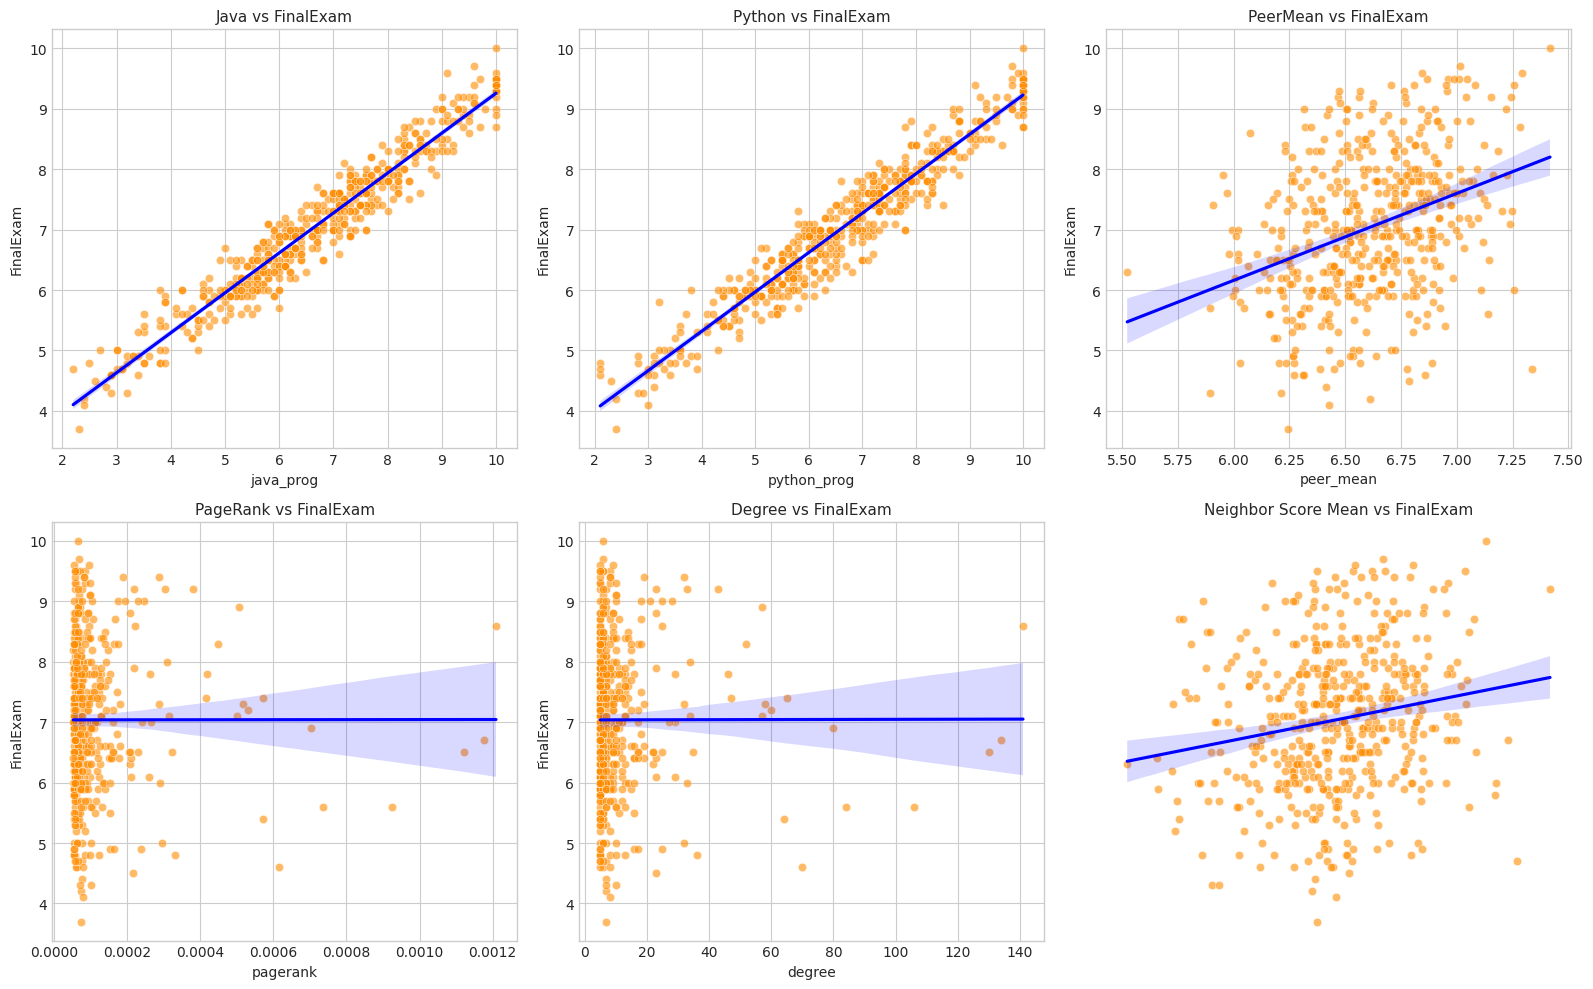

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

relations = [
    ('java_prog', 'Java vs FinalExam'),
    ('python_prog', 'Python vs FinalExam'),
    ('peer_mean', 'PeerMean vs FinalExam'),
    ('pagerank', 'PageRank vs FinalExam'),
    ('degree', 'Degree vs FinalExam'),
    ('neighbor_score_mean', 'Neighbor Score Mean vs FinalExam')
]

for idx, (col, title) in enumerate(relations):
    sns.scatterplot(data=df.sample(500, random_state=42), x=col, y='FinalExam', ax=axes[idx], alpha=0.6, color='darkorange')
    sns.regplot(data=df.sample(500, random_state=42), x=col, y='FinalExam', ax=axes[idx], scatter=False, color='blue')
    axes[idx].set_title(title, fontsize=11)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('FinalExam')

# Ẩn trục biểu đồ cuối cùng không sử dụng
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../figures/05_feature_relationships.png', dpi=150)
plt.show()

### PHẦN 17: TRỰC QUAN HÓA MẠNG LƯỚI XÃ HỘI (SOCIAL NETWORK VISUALIZATION)
Chúng ta sẽ trực quan hóa một đồ thị con (subgraph) mẫu gồm 500 nút (nodes) để quan sát hình thái mạng lưới (network topology), vẽ phân phối bậc (degree distribution) và biểu diễn cấu trúc cộng đồng được phát hiện bằng thuật toán cộng đồng Louvain (Louvain community algorithm).

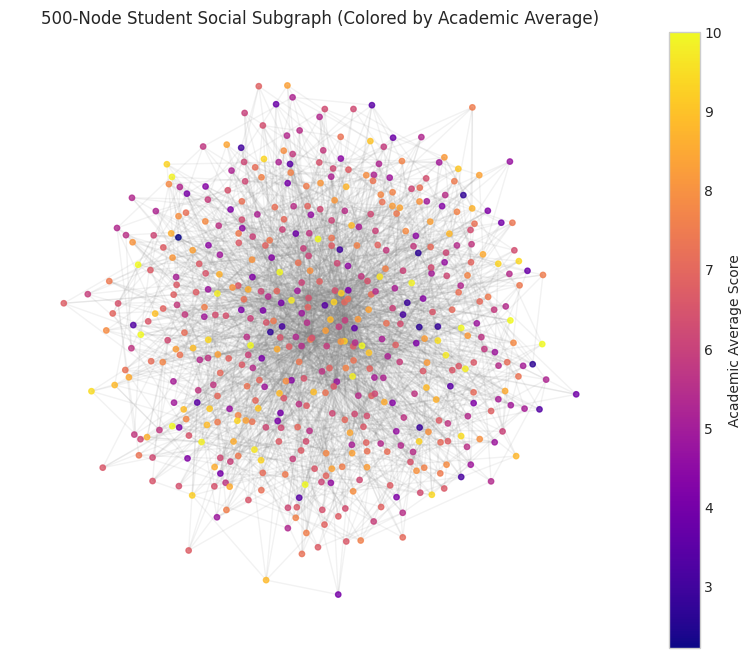

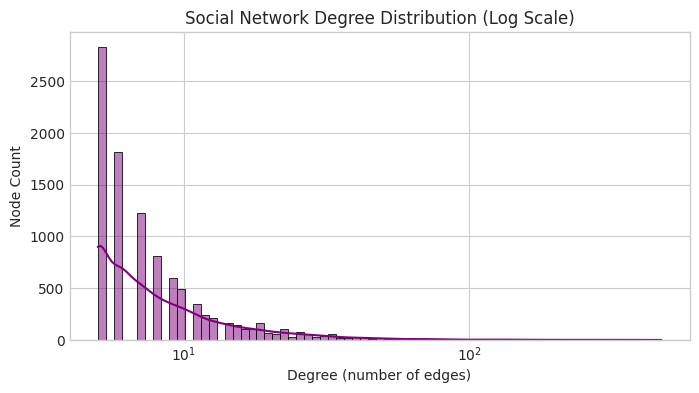

Detected 14 communities in the student social network.


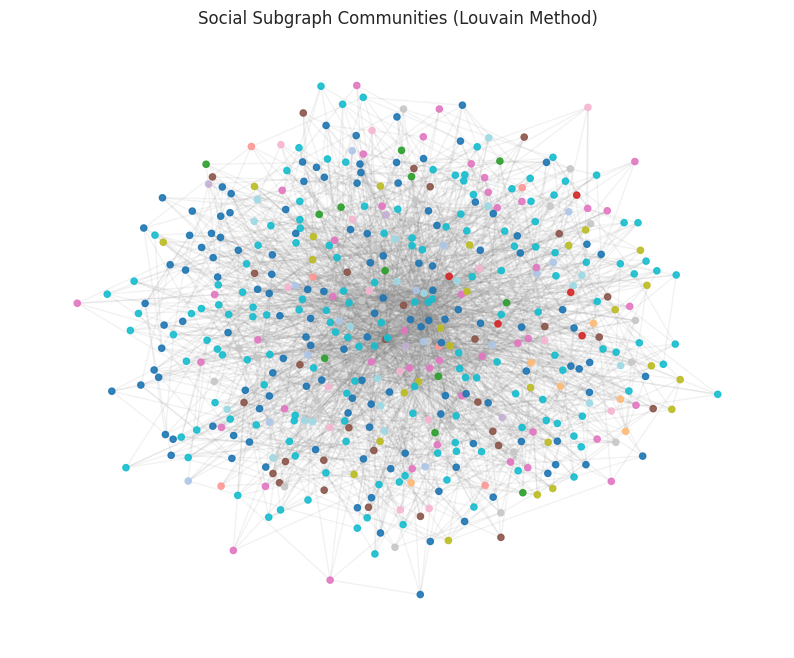

In [17]:
# Trích xuất đồ thị con 500 nút để hiển thị cấu trúc bố cục rõ ràng
subgraph_nodes = list(range(500))
sub_G = G.subgraph(subgraph_nodes)

# Vẽ cấu trúc hình học mạng lưới (network layout)
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(sub_G, seed=42, k=0.15)
nx.draw_networkx_nodes(sub_G, pos, node_size=15, node_color=student_avg_score[subgraph_nodes], cmap='plasma', alpha=0.8)
nx.draw_networkx_edges(sub_G, pos, alpha=0.1, edge_color='gray')
plt.title('500-Node Student Social Subgraph (Colored by Academic Average)', fontsize=12)
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=student_avg_score[subgraph_nodes].min(), vmax=student_avg_score[subgraph_nodes].max()))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Academic Average Score')
plt.axis('off')
plt.savefig('../figures/06_social_subgraph.png', dpi=150)
plt.show()

# Vẽ biểu đồ phân phối bậc (Degree Distribution)
plt.figure(figsize=(8, 4))
sns.histplot(degree, kde=True, color='purple', log_scale=(True, False))
plt.title('Social Network Degree Distribution (Log Scale)', fontsize=12)
plt.xlabel('Degree (number of edges)')
plt.ylabel('Node Count')
plt.savefig('../figures/07_degree_distribution.png', dpi=150)
plt.show()

# Phát hiện cấu trúc cộng đồng bằng thuật toán Louvain
communities = list(nx.community.louvain_communities(G, seed=42))
community_mapping = {}
for comm_id, nodes in enumerate(communities):
    for node in nodes:
        community_mapping[node] = comm_id

community_list = [community_mapping[i] for i in range(N)]
df['community'] = community_list

print(f"Detected {len(communities)} communities in the student social network.")

# Vẽ đồ thị con được tô màu theo cộng đồng (top 5 cộng đồng lớn nhất trong đồ thị con 500 nút)
sub_comm = [community_mapping[node] for node in subgraph_nodes]
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(sub_G, pos, node_size=20, node_color=sub_comm, cmap='tab20', alpha=0.9)
nx.draw_networkx_edges(sub_G, pos, alpha=0.1, edge_color='gray')
plt.title('Social Subgraph Communities (Louvain Method)', fontsize=12)
plt.axis('off')
plt.savefig('../figures/08_subgraph_communities.png', dpi=150)
plt.show()

### PHẦN 18: KHÁM PHÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE EXPLORATION)
Chúng ta tiến hành khám phá mức độ quan trọng của các đặc trưng (feature importances) bằng thuật toán hồi quy thông tin tương hỗ (Mutual Information regression) và mô hình hồi quy rừng ngẫu nhiên (Random Forest regression) trên các đặc trưng dạng bảng (tabular features).

Calculating Mutual Information scores...


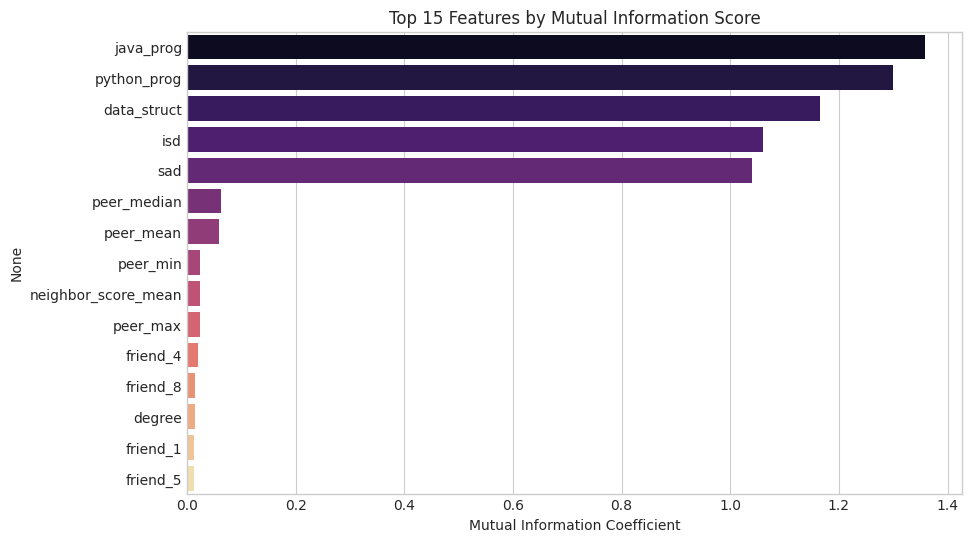

Training Random Forest Regressor for feature importance extraction...


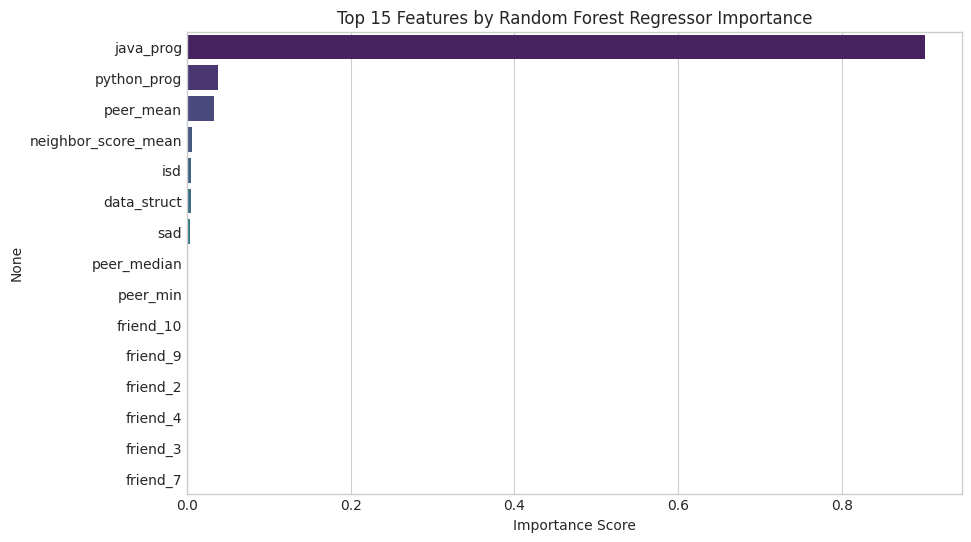

In [18]:
X_tabular = df.drop(columns=['FinalExam', 'community'])
y_tabular = df['FinalExam']

# Độ quan trọng dựa trên thông tin tương hỗ (Mutual Information Importance)
print("Calculating Mutual Information scores...")
mi_scores = mutual_info_regression(X_tabular, y_tabular, random_state=42)
mi_series = pd.Series(mi_scores, index=X_tabular.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.head(15).values, y=mi_series.head(15).index, palette='magma')
plt.title('Top 15 Features by Mutual Information Score', fontsize=12)
plt.xlabel('Mutual Information Coefficient')
plt.savefig('../figures/09_mutual_information.png', dpi=150)
plt.show()

# Độ quan trọng đặc trưng bằng mô hình rừng ngẫu nhiên (Random Forest)
print("Training Random Forest Regressor for feature importance extraction...")
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_tabular, y_tabular)
rf_importance = pd.Series(rf.feature_importances_, index=X_tabular.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importance.head(15).values, y=rf_importance.head(15).index, palette='viridis')
plt.title('Top 15 Features by Random Forest Regressor Importance', fontsize=12)
plt.xlabel('Importance Score')
plt.savefig('../figures/10_rf_importance.png', dpi=150)
plt.show()

### PHẦN 19: GIẢM SỐ CHIỀU DỮ LIỆU (DIMENSIONALITY REDUCTION)
Chúng ta thực hiện các kỹ thuật giảm số chiều dữ liệu (dimensionality reduction) để biểu diễn các đặc trưng sinh viên nhiều chiều lên không gian 2D trực quan:
- **Phân tích thành phần chính (PCA)**
- **Kỹ thuật t-SNE** (chạy trên một mẫu gồm 2,000 sinh viên để tăng tốc độ thực thi)
Các biểu đồ sẽ được tô màu theo biến mục tiêu `FinalExam`.

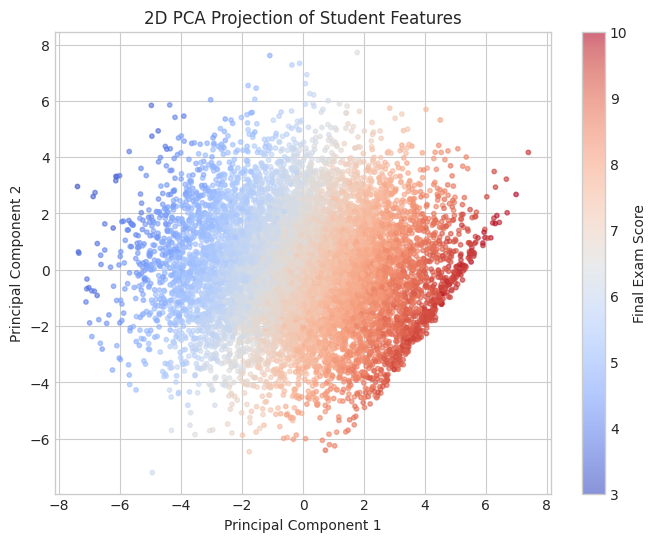

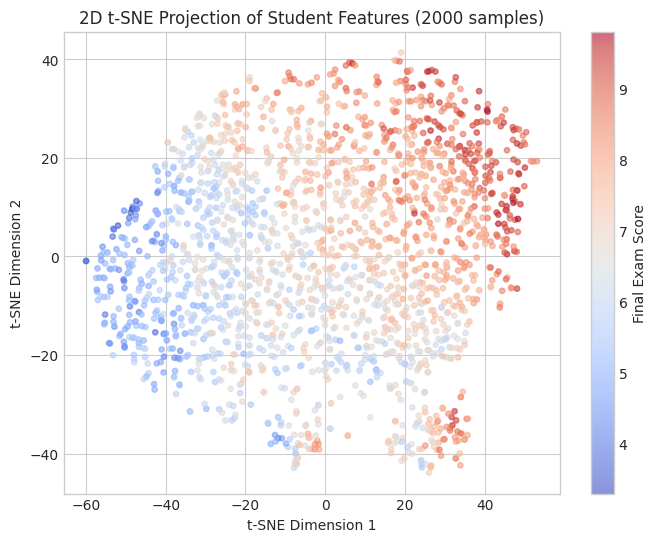

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tabular)

# Thực hiện phân tích thành phần chính (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_tabular, cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(scatter, label='Final Exam Score')
plt.title('2D PCA Projection of Student Features', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('../figures/11_pca_projection.png', dpi=150)
plt.show()

# Thực hiện kỹ thuật t-SNE (Mẫu 2000 nút để chạy nhanh hơn)
sample_idx = np.random.choice(N, 2000, replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled[sample_idx])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_tabular.values[sample_idx], cmap='coolwarm', alpha=0.6, s=15)
plt.colorbar(scatter, label='Final Exam Score')
plt.title('2D t-SNE Projection of Student Features (2000 samples)', fontsize=12)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('../figures/12_tsne_projection.png', dpi=150)
plt.show()

### PHẦN 20: LƯU BỘ DỮ LIỆU (SAVE DATASET)
Cuối cùng, chúng ta lưu bộ dữ liệu đầy đủ đã qua xử lý vào tệp tin `data/processed/dataset.csv`.

In [20]:
# Lưu bộ dữ liệu hoàn chỉnh vào thư mục chứa dữ liệu đã xử lý (processed folder)
df.to_csv("../data/processed/dataset.csv", index=False)
print("Complete dataset successfully saved to data/processed/dataset.csv")
print("Data shape:", df.shape)

Complete dataset successfully saved to data/processed/dataset.csv
Data shape: (10000, 28)
